Question 10<br>
Section (a) - Bilateral filtering
$$
I_{\text{out}}(x,y) = \frac{1}{W(x,y)} \sum_{i,j} I(i,j)\,
\exp\left(-\frac{(x-i)^2 + (y-j)^2}{2\sigma_s^2}\right)\,
\exp\left(-\frac{\left(I(x,y) - I(i,j)\right)^2}{2\sigma_r^2}\right)
$$

In [1]:
import numpy as np

def bilateral_filter(img, kernel_size, sigma_s, sigma_r):
    assert kernel_size % 2 == 1, "Kernel size must be odd"

    pad = kernel_size // 2
    h, w = img.shape

    # Pad image
    padded = np.pad(img, pad, mode='edge')

    # Output
    output = np.zeros_like(img, dtype=np.float32)

    # Precompute spatial Gaussian (constant for all pixels)
    ax = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))

    # Loop through image
    for i in range(h):
        for j in range(w):
            # Extract window
            window = padded[i:i+kernel_size, j:j+kernel_size]

            # Center pixel
            center = padded[i+pad, j+pad]

            # Range Gaussian (depends on intensity difference)
            range_weight = np.exp(-((window - center)**2) / (2 * sigma_r**2))

            # Combine weights
            weights = spatial * range_weight

            # Normalize
            W = np.sum(weights)

            # Weighted sum
            output[i, j] = np.sum(window * weights) / W

    return np.clip(output, 0, 255).astype(np.uint8)

Section b,c and d.

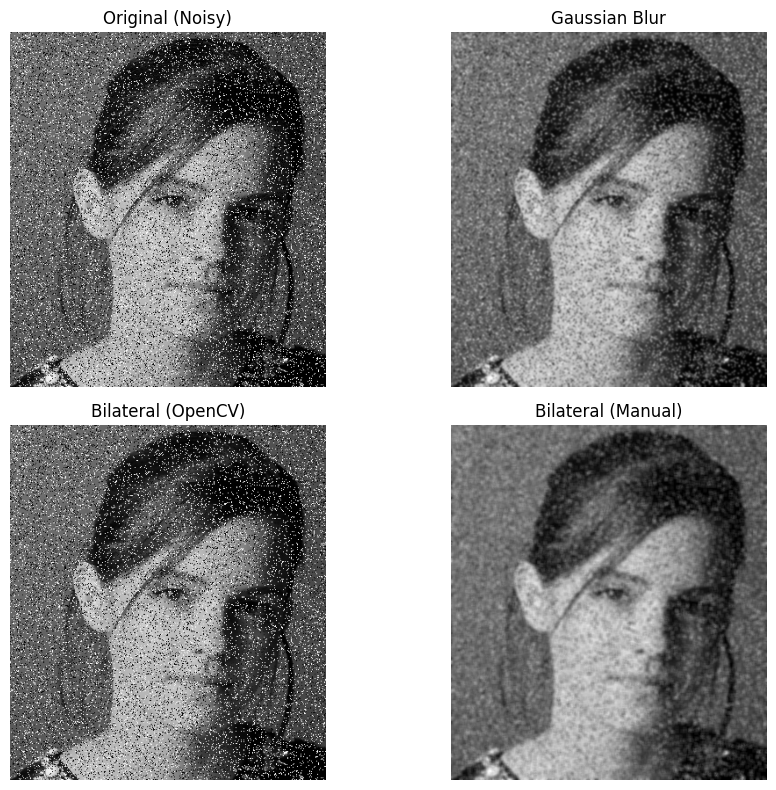

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('emma-noise.jpg', cv.IMREAD_GRAYSCALE)

# (b) Gaussian smoothing
gaussian = cv.GaussianBlur(img, (5,5), 1.0)

# (c) OpenCV bilateral filter
bilateral_cv = cv.bilateralFilter(
    img,
    d=5,
    sigmaColor=25,
    sigmaSpace=2
)

# (d) Manual bilateral filter
bilateral_manual = bilateral_filter(
    img,
    kernel_size=5,
    sigma_s=2,
    sigma_r=25
)

# Show results
fig, ax = plt.subplots(2, 2, figsize=(10,8))

ax[0,0].imshow(img, cmap='gray')
ax[0,0].set_title('Original (Noisy)')
ax[0,0].axis('off')

ax[0,1].imshow(gaussian, cmap='gray')
ax[0,1].set_title('Gaussian Blur')
ax[0,1].axis('off')

ax[1,0].imshow(bilateral_cv, cmap='gray')
ax[1,0].set_title('Bilateral (OpenCV)')
ax[1,0].axis('off')

ax[1,1].imshow(bilateral_manual, cmap='gray')
ax[1,1].set_title('Bilateral (Manual)')
ax[1,1].axis('off')

plt.tight_layout()
plt.show()